# Dependencies:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("Running")

Running


# Data Cleaning

In [2]:
users_df = pd.read_excel("archive/users.xlsx")
events_df = pd.read_excel("archive/events.xlsx")

print("--USER DATA--")
display(users_df.head())

print("--EVENT DATA--")
display(events_df.head())

--USER DATA--


,user_id,install_date
0,1,2024-01-07
1,2,2024-01-20
2,3,2024-01-29
3,4,2024-01-15
4,5,2024-01-11


--EVENT DATA--


,user_id,event_date,event_type
0,1,2024-01-07,session_start
1,1,2024-01-08,session_start
2,1,2024-01-09,session_start
3,1,2024-01-10,session_start
4,1,2024-01-11,session_start


In [3]:
users_df.info()
events_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       5000 non-null   int64         
 1   install_date  5000 non-null   datetime64[us]
dtypes: datetime64[us](1), int64(1)
memory usage: 78.3 KB
<class 'pandas.DataFrame'>
RangeIndex: 27291 entries, 0 to 27290
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     27291 non-null  int64         
 1   event_date  27291 non-null  datetime64[us]
 2   event_type  27291 non-null  str           
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 639.8 KB


In [4]:
user_activity = events_df.groupby("user_id").agg(
    total_sessions = ("event_type","count"),
    last_session = ("event_date","max")
).reset_index()

df = pd.merge(user_activity,users_df,on="user_id",how="left")
dataset_max_date = events_df["event_date"].max()

df["days_active"] = (df["last_session"] - df["install_date"]).dt.days
df["days_inactive"] = (dataset_max_date - df["last_session"]).dt.days
df["account_age"] = (dataset_max_date - df["install_date"]).dt.days

df["churn"] = (df["days_inactive"]>7).astype(int)

print("--MASTER DATASET--")
df.head()

--MASTER DATASET--


,user_id,total_sessions,last_session,install_date,days_active,days_inactive,account_age,churn
0,1,6,2024-01-12,2024-01-07,5,53,58,1
1,2,4,2024-01-23,2024-01-20,3,42,45,1
2,3,11,2024-02-08,2024-01-29,10,26,36,1
3,4,2,2024-01-16,2024-01-15,1,49,50,1
4,5,6,2024-01-16,2024-01-11,5,49,54,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         5000 non-null   int64         
 1   total_sessions  5000 non-null   int64         
 2   last_session    5000 non-null   datetime64[us]
 3   install_date    5000 non-null   datetime64[us]
 4   days_active     5000 non-null   int64         
 5   days_inactive   5000 non-null   int64         
 6   account_age     5000 non-null   int64         
 7   churn           5000 non-null   int64         
dtypes: datetime64[us](2), int64(6)
memory usage: 312.6 KB


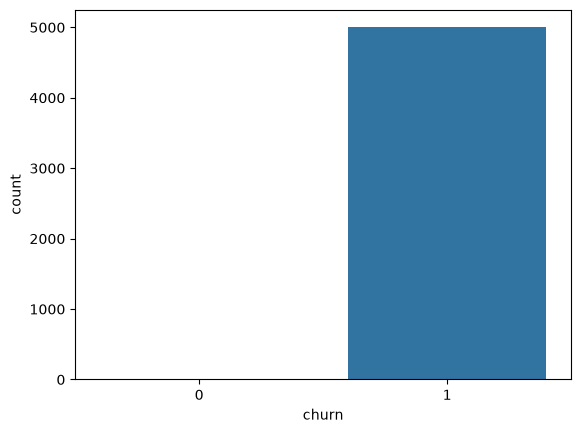

In [6]:
sns.countplot(x="churn", data=df)
plt.show()

In [7]:
df["days_inactive"].describe()

count    5000.000000
mean       44.960400
std        10.070547
min         0.000000
25%        37.000000
50%        45.000000
75%        53.000000
max        64.000000
Name: days_inactive, dtype: float64

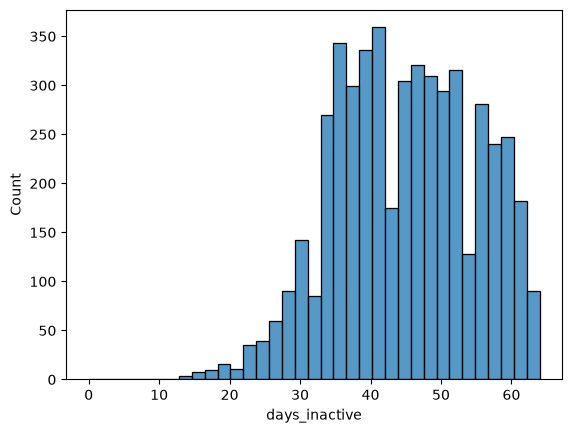

In [8]:
sns.histplot(data=df['days_inactive'])
plt.show()

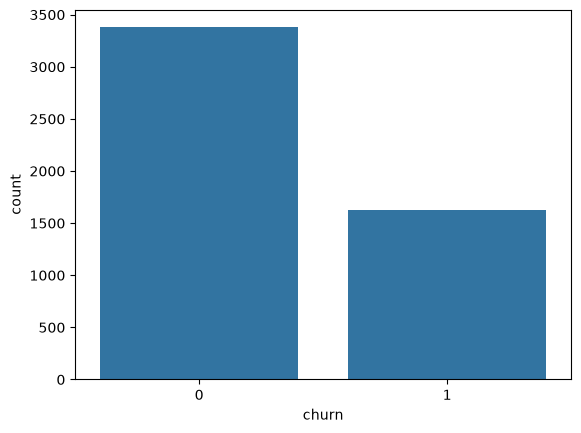

In [9]:
df['churn'] = (df["days_inactive"]>50).astype(int)
sns.countplot(x="churn",data=df)
plt.show()

In [10]:
cm = df.corr(numeric_only=True)
print(cm)

                 user_id  total_sessions  days_active  days_inactive  \
user_id         1.000000       -0.006636    -0.006636       0.013721   
total_sessions -0.006636        1.000000     1.000000      -0.493259   
days_active    -0.006636        1.000000     1.000000      -0.493259   
days_inactive   0.013721       -0.493259    -0.493259       1.000000   
account_age     0.012027       -0.002586    -0.002586       0.871155   
churn           0.007362       -0.274958    -0.274958       0.788802   

                account_age     churn  
user_id            0.012027  0.007362  
total_sessions    -0.002586 -0.274958  
days_active       -0.002586 -0.274958  
days_inactive      0.871155  0.788802  
account_age        1.000000  0.751588  
churn              0.751588  1.000000  


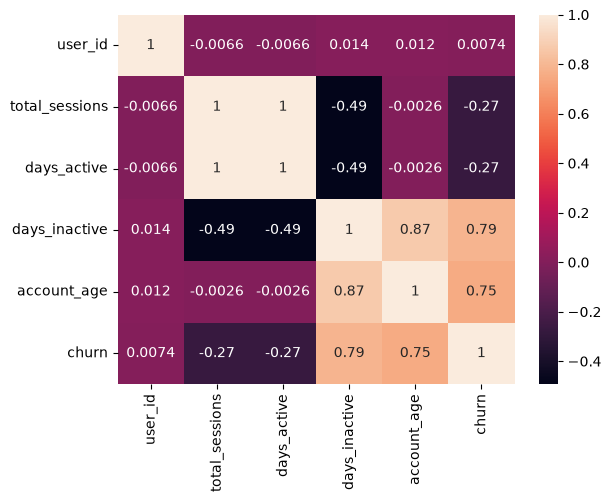

In [11]:
sns.heatmap(cm,annot=True)
plt.show()

In [12]:
df = df.drop(["days_inactive","user_id","days_active","last_session","install_date"],axis="columns")
df.head()

,total_sessions,account_age,churn
0,6,58,1
1,4,45,0
2,11,36,0
3,2,50,0
4,6,54,0


In [13]:
y = df["churn"]
df = df.drop('churn',axis='columns')
X = df

In [23]:
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled[:3])

[[-0.69955045  1.21604083]
 [-0.69955045  1.10110856]
 [ 0.12007515  0.41151497]]
